Running Standard Simulation (N=5000, T=1440h)...
Standard Model Time: 105.32 seconds

Running Optimized Simulation (N=5000, T=1440h)...
Optimized Model Time: 75.03 seconds

Speedup: 1.40x faster


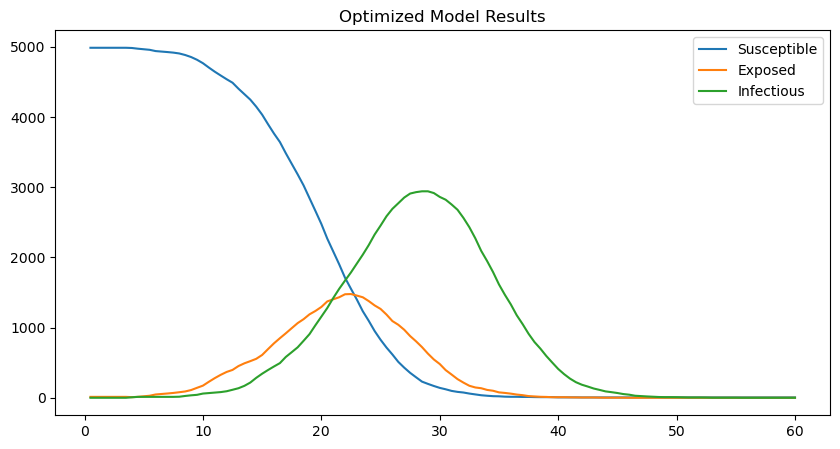

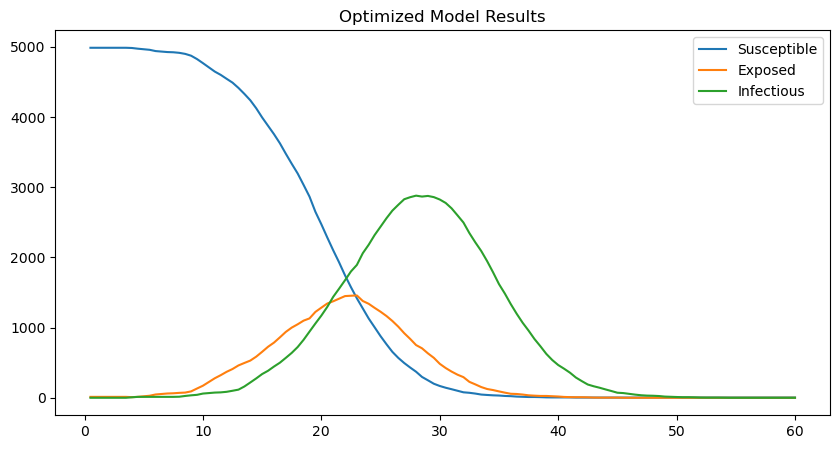

In [ ]:
import time
import pandas as pd
import matplotlib.pyplot as plt

# Import BOTH modules
import infection_model_1 as standard_model
import infection_model_opt as opt_model


DAYS = 60
# Define the params for the STANDARD model
example_params_standard = standard_model.Params(
    T=DAYS * 24, # Converted 10 days to hours (assuming T in logic is hours)
    N=5000,
    alpha=3,
    exposed=13,
    ratios=standard_model.AgentTypeRatio(retired=0.2, adult=0.6, child=0.2),
    schools=1,
    primary_care=5,
    hospitals=1,
    other_working_places=2,
    public_places=6,
)

# Define the params for the OPTIMIZED model
# (Note: Using the Params class from the opt module to ensure type compatibility)
example_params_opt = opt_model.Params(
    T=DAYS * 24,
    N=5000,
    alpha=3,
    exposed=13,
    ratios=opt_model.AgentTypeRatio(retired=0.2, adult=0.6, child=0.2),
    schools=1,
    primary_care=5,
    hospitals=1,
    other_working_places=2,
    public_places=6,
)

print(f"Running Standard Simulation (N={example_params_standard.N}, T={example_params_standard.T}h)...")
start_time = time.time()
sim_std = standard_model.Simulation(params=example_params_standard, seed=42)
sim_std.init()
sim_std.run(dt=12.0)
std_duration = time.time() - start_time
print(f"Standard Model Time: {std_duration:.2f} seconds")

print(f"\nRunning Optimized Simulation (N={example_params_opt.N}, T={example_params_opt.T}h)...")
start_time = time.time()
sim_opt = opt_model.Simulation(params=example_params_opt, seed=42)
sim_opt.init()
sim_opt.run(dt=12.0)
opt_duration = time.time() - start_time
print(f"Optimized Model Time: {opt_duration:.2f} seconds")

print(f"\nSpeedup: {std_duration / opt_duration:.2f}x faster")


# Optional: Validate results match by plotting Optimized results
df = pd.DataFrame(sim_std.get_stats_df())
df["days"] = df["time"] / 24
plt.figure(figsize=(10, 5))
plt.plot(df["days"], df["S"], label="Susceptible")
plt.plot(df["days"], df["E"], label="Exposed")
plt.plot(df["days"], df["I1"] + df["I2"] + df["I0"], label="Infectious")
plt.legend()
plt.title("Not Optimized Model Results")
plt.show()

# Optional: Validate results match by plotting Optimized results
df = pd.DataFrame(sim_opt.get_stats_df())
df["days"] = df["time"] / 24
plt.figure(figsize=(10, 5))
plt.plot(df["days"], df["S"], label="Susceptible")
plt.plot(df["days"], df["E"], label="Exposed")
plt.plot(df["days"], df["I1"] + df["I2"] + df["I0"], label="Infectious")
plt.legend()
plt.title("Optimized Model Results")
plt.show()